### Feature extraction + XGBoost modelling, in a pipeline

Running 5-fold CV with RandomizedSearchCV & Early Stopping...

Fold 1: Best Inner F1 = 0.9148 | Test Acc = 0.9415 | Test F1 = 0.9400
Fold 2: Best Inner F1 = 0.9194 | Test Acc = 0.9810 | Test F1 = 0.9816
Fold 3: Best Inner F1 = 0.9201 | Test Acc = 0.9694 | Test F1 = 0.9688
Fold 4: Best Inner F1 = 0.9388 | Test Acc = 0.9492 | Test F1 = 0.9460
Fold 5: Best Inner F1 = 0.9406 | Test Acc = 0.9134 | Test F1 = 0.9089
--------------------------------------------------
Average Test Accuracy: 0.9509 (+/- 0.0234)
Overall Out-of-Fold Macro F1: 0.9496
Logged run to ../dataset/experiment_logs.jsonl (JSONL)

Top 20 Most Important Features:
tGravityAcc-mean()-X                0.042545
fBodyAcc-bandsEnergy()-17,24.1      0.033924
fBodyBodyGyroMag-maxInds            0.031207
fBodyAcc-bandsEnergy()-1,8.1        0.027828
fBodyAccJerk-bandsEnergy()-41,48    0.023696
tBodyAcc-std()-X                    0.022282
fBodyGyro-bandsEnergy()-17,24       0.021867
tBodyAccJerk-entropy()-X            0.020858
tBodyGyr

/var/folders/s2/_qxs1d_57r18ktd8jtkpm0sw0000gn/T/ipykernel_87679/2225409.py:250: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_fi.head(20).values, y=mean_fi.head(20).index, palette='viridis')


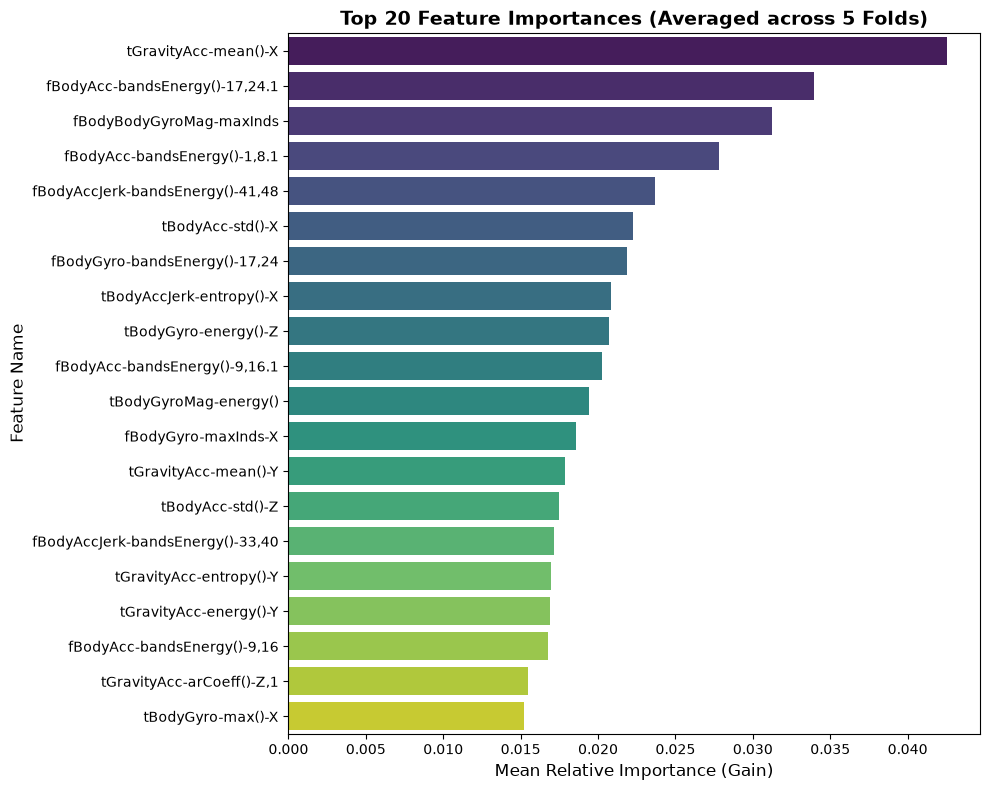

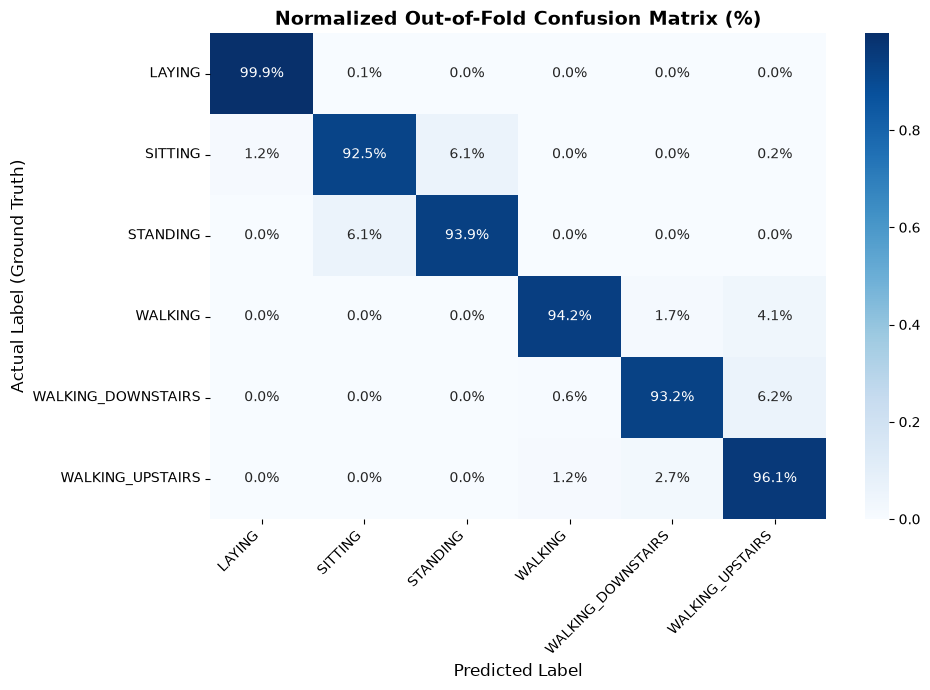

In [1]:
import os
import json
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import xgboost as xgb

note_for_docs = "30% test, 70% train (internal val for early stopping + RandomizedSearchCV). 5 fold GroupKFold."

def log_experiment(params, accuracy, f1, cm_normalized, labels, filepath="experiment_logs.jsonl", mode="jsonl"):
    """
    Logs hyperparameter tuning runs to either JSON Lines or CSV.
    """
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    if mode == "jsonl":
        cm_dict = {
            actual: {pred: round(float(cm_normalized[i, j] * 100), 2) 
                     for j, pred in enumerate(labels)}
            for i, actual in enumerate(labels)
        }
        
        entry = {
            "timestamp": timestamp,
            "accuracy": round(float(accuracy), 4),
            "f1_score": round(float(f1), 4),
            "hyperparameters": params,
            "confusion_matrix_pct": cm_dict,
            "note": note_for_docs
        }
        
        os.makedirs(os.path.dirname(filepath), exist_ok=True) if os.path.dirname(filepath) else None
        with open(filepath, "a") as f:
            f.write(json.dumps(entry) + "\n")
        print(f"Logged run to {filepath} (JSONL)")

    elif mode == "csv":
        row = {
            "timestamp": timestamp,
            "accuracy": round(float(accuracy), 4),
            "f1_score": round(float(f1), 4),
            **{f"param_{k}": v for k, v in params.items()}
        }
        
        for i, actual in enumerate(labels):
            for j, pred in enumerate(labels):
                col_name = f"cm_{actual}_{pred}"
                row[col_name] = round(float(cm_normalized[i, j] * 100), 2)
        
        df_row = pd.DataFrame([row])
        file_exists = os.path.isfile(filepath)
        df_row.to_csv(filepath, mode="a", index=False, header=not file_exists)
        print(f"Logged run to {filepath} (CSV)")


# 1. Pipeline-Safe Correlation Filter
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.95):
        self.threshold = threshold
        self.to_drop_indices_ = []

    def fit(self, X, y=None):
        df_x = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        corr_matrix = df_x.corr().abs()
        
        upper_tri = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        
        self.to_drop_indices_ = [
            i for i, col in enumerate(upper_tri.columns) 
            if any(upper_tri[col] > self.threshold)
        ]
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            return X.drop(X.columns[self.to_drop_indices_], axis=1).values
        return np.delete(X, self.to_drop_indices_, axis=1)


def get_pipeline_feature_names(pipeline, initial_feature_names):
    """
    Tracks surviving feature names through VarianceThreshold and CorrelationFilter.
    """
    current_features = list(initial_feature_names)
    
    if 'variance' in pipeline.named_steps:
        vt = pipeline.named_steps['variance']
        current_features = [f for f, keep in zip(current_features, vt.get_support()) if keep]
        
    if 'correlation' in pipeline.named_steps:
        cf = pipeline.named_steps['correlation']
        current_features = [f for i, f in enumerate(current_features) if i not in cf.to_drop_indices_]
        
    return current_features


# 2. Load and Prepare Data
df = pd.read_csv('../dataset/full_wo_fft.csv')

X = df.drop(columns=['Activity', 'subject'])
groups = df['subject']

le = LabelEncoder()
y = le.fit_transform(df['Activity'])
labels = le.classes_

# Hyperparameter Search Space
param_distributions = {
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 5, 6, 8],
    'n_estimators': [500, 800, 1000],
    'subsample': [0.5, 0.6, 0.8],
    'colsample_bytree': [0.5, 0.7, 0.9],
    'min_child_weight': [3, 5, 7, 10],
    'reg_lambda': [1.0, 3.0, 5.0, 10.0],
    'reg_alpha': [0, 0.1, 1.0],
    'gamma': [0, 0.1, 0.2]
}

# 3. Define Preprocessing Pipeline
feature_pipeline = Pipeline([
    ('variance', VarianceThreshold(threshold=0.01)),
    ('correlation', CorrelationFilter(threshold=0.95))
])

# 4. Out-of-Fold Validation Loop with Nested Tuning & Early Stopping
outer_gkf = GroupKFold(n_splits=5)
internal_gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=69)

y_true_all = []
y_pred_all = []
test_scores = []
fold_feature_importances = []
best_params_per_fold = []

print("Running 5-fold CV with RandomizedSearchCV & Early Stopping...\n")

for fold, (train_idx, test_idx) in enumerate(outer_gkf.split(X, y, groups)):
    X_train_fold, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test = y[train_idx], y[test_idx]
    groups_train_fold = groups.iloc[train_idx]
    
    # Separate Fold Train into Sub-train (80%) and Validation (20%) by Subject
    subtrain_idx, val_idx = next(internal_gss.split(X_train_fold, y_train_fold, groups_train_fold))
    
    X_subtrain, X_val = X_train_fold.iloc[subtrain_idx], X_train_fold.iloc[val_idx]
    y_subtrain, y_val = y_train_fold[subtrain_idx], y_train_fold[val_idx]
    groups_subtrain = groups_train_fold.iloc[subtrain_idx]
    
    # Fit feature transformers strictly on sub-train
    X_subtrain_transformed = feature_pipeline.fit_transform(X_subtrain, y_subtrain)
    X_val_transformed = feature_pipeline.transform(X_val)
    X_test_transformed = feature_pipeline.transform(X_test)
    
    # Base Estimator with Early Stopping Configured
    base_xgb = xgb.XGBClassifier(
        early_stopping_rounds=20,
        eval_metric='mlogloss',
        random_state=69
    )
    
    # Inner GroupKFold for Search Space Evaluation
    inner_gkf = GroupKFold(n_splits=3)
    
    search = RandomizedSearchCV(
        estimator=base_xgb,
        param_distributions=param_distributions,
        n_iter=10,
        scoring='f1_macro',
        cv=inner_gkf,
        random_state=69,
        n_jobs=-1
    )
    
    # Fit RandomizedSearchCV passing transformed validation set to fit_params
    search.fit(
        X_subtrain_transformed, 
        y_subtrain,
        groups=groups_subtrain,
        eval_set=[(X_val_transformed, y_val)],
        verbose=False
    )
    
    best_model = search.best_estimator_
    best_params_per_fold.append(search.best_params_)
    
    # Evaluate Best Model on Test Fold
    preds = best_model.predict(X_test_transformed)
    test_acc = accuracy_score(y_test, preds)
    test_f1 = f1_score(y_test, preds, average='macro')
    
    test_scores.append(test_acc)
    y_true_all.extend(y_test)
    y_pred_all.extend(preds)
    
    # Extract Feature Importances
    surviving_features = get_pipeline_feature_names(feature_pipeline, X.columns)
    fold_fi = pd.Series(best_model.feature_importances_, index=surviving_features)
    fold_feature_importances.append(fold_fi)
    
    print(f"Fold {fold+1}: Best Inner F1 = {search.best_score_:.4f} | Test Acc = {test_acc:.4f} | Test F1 = {test_f1:.4f}")

# Calculate Aggregated Out-of-Fold Metrics
mean_test_acc = np.mean(test_scores)
std_test_acc = np.std(test_scores)

oof_f1_macro = f1_score(y_true_all, y_pred_all, average='macro')

print("-" * 50)
print(f"Average Test Accuracy: {mean_test_acc:.4f} (+/- {std_test_acc:.4f})")
print(f"Overall Out-of-Fold Macro F1: {oof_f1_macro:.4f}")

# 5. Calculate Out-of-Fold Confusion Matrix
cm_normalized = confusion_matrix(y_true_all, y_pred_all, normalize='true')

# Most common best parameters across folds
most_common_params = best_params_per_fold[0]

# 6. Log Experiment
log_experiment(
    params=most_common_params,
    accuracy=mean_test_acc,
    f1=oof_f1_macro,
    cm_normalized=cm_normalized,
    labels=labels,
    filepath="../dataset/experiment_logs.jsonl",
    mode="jsonl"
)

# 7. Aggregate and Output Feature Importances
df_fi = pd.concat(fold_feature_importances, axis=1).fillna(0)
mean_fi = df_fi.mean(axis=1).sort_values(ascending=False)

print("\nTop 20 Most Important Features:")
print(mean_fi.head(20))

# 8. Plot Top Feature Importances
plt.figure(figsize=(10, 8))
sns.barplot(x=mean_fi.head(20).values, y=mean_fi.head(20).index, palette='viridis')
plt.title('Top 20 Feature Importances (Averaged across 5 Folds)', fontsize=14, fontweight='bold')
plt.xlabel('Mean Relative Importance (Gain)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

# 9. Plot Confusion Matrix Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_normalized, 
    annot=True, 
    fmt='.1%', 
    cmap='Blues', 
    xticklabels=labels, 
    yticklabels=labels
)

plt.title('Normalized Out-of-Fold Confusion Matrix (%)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label (Ground Truth)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()